## GROUP 5 - SYNDICATE
## CAT 2
## 138547 - Dee Emmanuel 
## 169282 - Mathews Zimba
## 168653 STEPHEN WANJOGU NGATARA
## 169085 ABRAHAM KUOL AJUONG
## 112409 Ian Kahare Gichero

## First thing to do here is to import libraries 

In [1]:
#import the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
#warnings.filterwarnings('ignore')



## Let's load our Dataset 

In [2]:
data = pd.read_csv("/Users/dengachiek/Downloads/MobilePriceRange.csv")
data.head()

,BatteryPower,InternalMemory,ClockSpeed,NoOfCores,RAM,TalkTime,DualSim,3G,4G,WiFi,...,MobileDepth,MobileWeight,TouchScreen,ScreenHeight,ScreenWidth,FrontCameraPx,RearCameraPX,PxHeight,PxWeight,PriceRange
0,842,7,2.2,2,2549,19,0,0,0,1,...,0.6,188,0,9,7,1,2,20,756,Medium
1,1021,53,0.5,3,2631,7,1,1,1,0,...,0.7,136,1,17,3,0,6,905,1988,High
2,563,41,0.5,5,2603,9,1,1,1,0,...,0.9,145,1,11,2,2,6,1263,1716,High
3,615,10,2.5,6,2769,11,0,1,0,0,...,0.8,131,0,16,8,0,9,1216,1786,High
4,1821,44,1.2,2,1411,15,0,1,1,0,...,0.6,141,1,8,2,13,14,1208,1212,Medium


In [3]:
# check the shape of our dataset
data.shape

(2000, 21)

In [5]:
# check what are our data types 
data.dtypes

BatteryPower        int64
InternalMemory      int64
ClockSpeed        float64
NoOfCores           int64
RAM                 int64
TalkTime            int64
DualSim             int64
3G                  int64
4G                  int64
WiFi                int64
Bluetooth           int64
MobileDepth       float64
MobileWeight        int64
TouchScreen         int64
ScreenHeight        int64
ScreenWidth         int64
FrontCameraPx       int64
RearCameraPX        int64
PxHeight            int64
PxWeight            int64
PriceRange         object
dtype: object

In [7]:
# check for duplicate values 
data.duplicated().sum()

np.int64(0)

In [8]:
# check for null values 
data.isnull().sum()

BatteryPower      0
InternalMemory    0
ClockSpeed        0
NoOfCores         0
RAM               0
TalkTime          0
DualSim           0
3G                0
4G                0
WiFi              0
Bluetooth         0
MobileDepth       0
MobileWeight      0
TouchScreen       0
ScreenHeight      0
ScreenWidth       0
FrontCameraPx     0
RearCameraPX      0
PxHeight          0
PxWeight          0
PriceRange        0
dtype: int64

 ## Now let's Explore the data set


In [12]:
print("INSIGHT 1: Perfect Balance")
print("Each price range has exactly 500 phones (25% each)")

print("This is good no class imbalance\n")

INSIGHT 1: Perfect Balance
Each price range has exactly 500 phones (25% each)
This is good no class imbalance



## The 2nd Insight will look at the Ram 

In [14]:
print("INSIGHT 2: RAM increases with Price Range")
ram_by_price = data.groupby('PriceRange')['RAM'].mean()
print("Average RAM:")
for price, ram in ram_by_price.items():
    print(f"  {price}: {ram:.0f} MB")
print()

INSIGHT 2: RAM increases with Price Range
Average RAM:
  High: 2583 MB
  Low: 785 MB
  Medium: 1679 MB
  VeryHigh: 3449 MB



## The 3rd Insight will look at the battery 

In [15]:
print("INSIGHT 3: Battery Power also increases with Price")
battery_by_price = data.groupby('PriceRange')['BatteryPower'].mean()
print("Average Battery Power:")
for price, batt in battery_by_price.items():
    print(f"  {price}: {batt:.0f} mAh")
print()

INSIGHT 3: Battery Power also increases with Price
Average Battery Power:
  High: 1228 mAh
  Low: 1117 mAh
  Medium: 1229 mAh
  VeryHigh: 1380 mAh



## The 4th Insight is to check the correlation between these two Battery and Ram

INSIGHT 4: RAM is the best predictor
RAM has strong relationship with price
Battery Power has moderate relationship



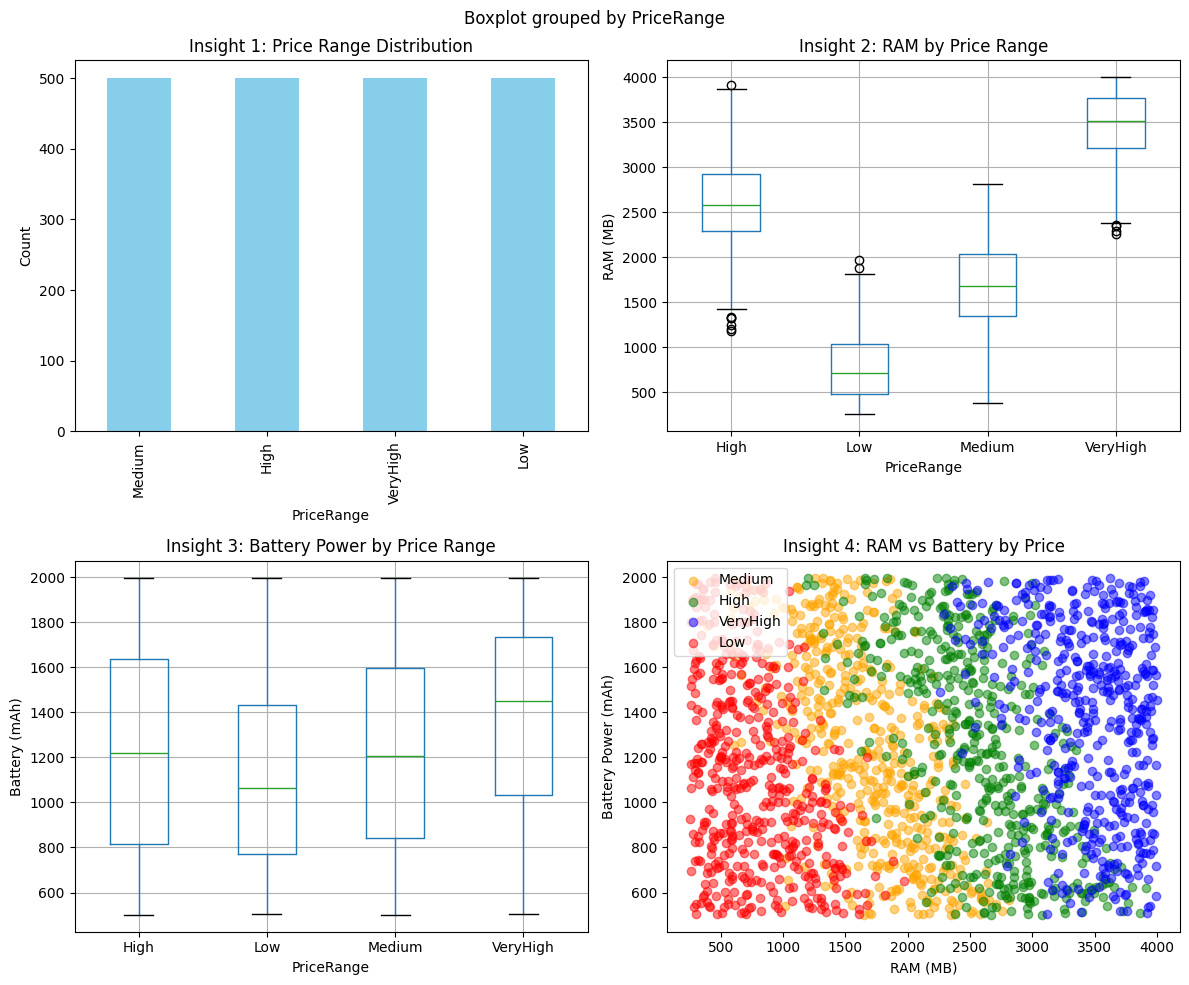

In [16]:
print("INSIGHT 4: RAM is the best predictor")
print("RAM has strong relationship with price")
print("Battery Power has moderate relationship\n")

# Create simple visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Count of each price range
data['PriceRange'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Insight 1: Price Range Distribution')
axes[0,0].set_ylabel('Count')

# Plot 2: RAM by price
data.boxplot(column='RAM', by='PriceRange', ax=axes[0,1])
axes[0,1].set_title('Insight 2: RAM by Price Range')
axes[0,1].set_ylabel('RAM (MB)')

# Plot 3: Battery by price
data.boxplot(column='BatteryPower', by='PriceRange', ax=axes[1,0])
axes[1,0].set_title('Insight 3: Battery Power by Price Range')
axes[1,0].set_ylabel('Battery (mAh)')

# Plot 4: Scatter plot RAM vs Battery colored by price
colors = {'Low': 'red', 'Medium': 'orange', 'High': 'green', 'VeryHigh': 'blue'}
for price in data['PriceRange'].unique():
    subset = data[data['PriceRange'] == price]
    axes[1,1].scatter(subset['RAM'], subset['BatteryPower'], 
                      c=colors[price], label=price, alpha=0.5)
axes[1,1].set_xlabel('RAM (MB)')
axes[1,1].set_ylabel('Battery Power (mAh)')
axes[1,1].set_title('Insight 4: RAM vs Battery by Price')
axes[1,1].legend()

plt.tight_layout()

plt.show()


## Let's take a look at the KNN 

K-NEAREST NEIGHBOURS
Training samples: 1400
Testing samples: 600

Finding best k...
k=1: accuracy = 0.7367
k=2: accuracy = 0.7317
k=3: accuracy = 0.7600
k=4: accuracy = 0.7617
k=5: accuracy = 0.7683
k=6: accuracy = 0.7717
k=7: accuracy = 0.7817
k=8: accuracy = 0.7833
k=9: accuracy = 0.7883
k=10: accuracy = 0.7900
k=11: accuracy = 0.7833
k=12: accuracy = 0.7833
k=13: accuracy = 0.7933
k=14: accuracy = 0.7833
k=15: accuracy = 0.7850
k=16: accuracy = 0.7850
k=17: accuracy = 0.7933
k=18: accuracy = 0.7867
k=19: accuracy = 0.7900
k=20: accuracy = 0.7883

✓ BEST K = 13 with accuracy = 0.7933


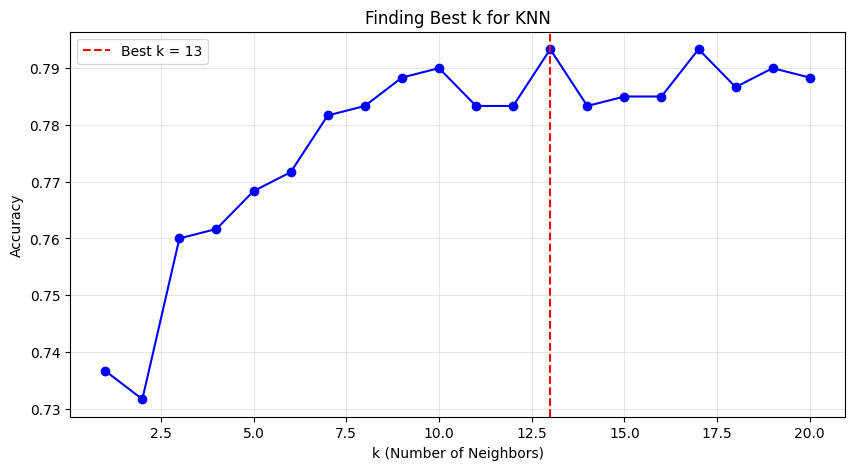


Final KNN Model (k=13):
Test Accuracy: 0.7933 (79.33%)


In [17]:
X = data[['RAM', 'BatteryPower']]  # For X it represents Features
y = data['PriceRange']              # and y is the Target

# So, first we shall our cleaned data Split into train and test (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# And then Scale the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("K-NEAREST NEIGHBOURS")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# let's find best k value
print("\nFinding best k...")
best_k = 1
best_accuracy = 0

k_values = range(1, 21)
accuracies = []

for k in k_values:
    # Create and train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Predict and check accuracy
    predictions = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)
    
    print(f"k={k}: accuracy = {accuracy:.4f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

print(f"\n✓ BEST K = {best_k} with accuracy = {best_accuracy:.4f}")

# Plot k vs accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Finding Best k for KNN')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Train final KNN with best k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_predictions = knn_final.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print(f"\nFinal KNN Model (k={best_k}):")
print(f"Test Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")

## Now let's create our Random Forest 

In [18]:
print("RANDOM FOREST (EAGER LEARNER)")
print("\nWhy Random Forest is an Eager Learner:")
print("It builds the forest (many trees) during training")
print("It learns patterns from data immediately")
print("When predicting, it just uses the pre-built model")
print("This is different from KNN which waits until prediction time")

# Create Random Forest with default settings
randomforest_default = RandomForestClassifier(random_state=42)
randomforest_default.fit(X_train, y_train)  # we shall not be needing any scaling 

# Now here we are Making predictions
randomforest_predictions = randomforest_default.predict(X_test)
randomforest_accuracy = accuracy_score(y_test, randomforest_predictions)

print(f"\nDefault Random Forest:")
print(f"Test Accuracy: {randomforest_accuracy:.4f} ({randomforest_accuracy*100:.2f}%)")
print(f"Number of trees: {randomforest_default.n_estimators}")
print(f"Max depth: {randomforest_default.max_depth} (None = unlimited)")

# Now let's Check feature 
importance = randomforest_default.feature_importances_
print(f"\nFeature Importance:")
print(f"  RAM: {importance[0]:.3f} ({importance[0]*100:.1f}%)")
print(f"  Battery: {importance[1]:.3f} ({importance[1]*100:.1f}%)")

RANDOM FOREST (EAGER LEARNER)

Why Random Forest is an Eager Learner:
It builds the forest (many trees) during training
It learns patterns from data immediately
When predicting, it just uses the pre-built model
This is different from KNN which waits until prediction time

Default Random Forest:
Test Accuracy: 0.7900 (79.00%)
Number of trees: 100
Max depth: None (None = unlimited)

Feature Importance:
  RAM: 0.770 (77.0%)
  Battery: 0.230 (23.0%)


## Let's tune the random forest 

In [24]:
# Try different hyperparameters manually (simple approach)
print("\nTrying different settings...")

best_randomforest = None
best_randomforest_accuracy = 0
best_params = {}

# Test different combinations
tree_counts = [50, 100, 200]
depths = [5, 10, 15, None]

results = []

for n_trees in tree_counts:
    for depth in depths:
        # Create Random Forest
        randomforest = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42
        )
        randomforest.fit(X_train, y_train)
        # randomforest.fit(X_train, y_train)

        # Test accuracy
        pred = randomforest.predict(X_test)
        acc = accuracy_score(y_test, pred)

        # create a dict
        results.append({
            'trees': n_trees,
            'depth': depth,
            'accuracy': acc
        })

        print(f"Trees={n_trees}, Depth={depth}: Accuracy={acc:.4f}")

        if acc > best_randomforest_accuracy:
            best_randomforest_accuracy = acc
            best_randomforest = randomforest
            best_params = {'trees': n_trees, 'depth': depth}

print(f"\n✓ BEST SETTINGS:")
print(f"  Number of trees: {best_params['trees']}")
print(f"  Max depth: {best_params['depth']}")
print(f"  Accuracy: {best_randomforest_accuracy:.4f} ({best_randomforest_accuracy*100:.2f}%)")

# Get predictions from best model
randomforest_tuned_predictions = best_randomforest.predict(X_test)

# Compare default vs tuned
print(f"\nComparison:")
print(f"  Default RF:  {randomforest_accuracy:.4f} ({randomforest_accuracy*100:.2f}%)")
print(f"  Tuned RF:    {best_randomforest_accuracy:.4f} ({best_randomforest_accuracy*100:.2f}%)")
print(f"  Improvement: {(best_randomforest_accuracy - randomforest_accuracy)*100:.2f} percentage points")


Trying different settings...
Trees=50, Depth=5: Accuracy=0.8183
Trees=50, Depth=10: Accuracy=0.7967
Trees=50, Depth=15: Accuracy=0.7933
Trees=50, Depth=None: Accuracy=0.7900
Trees=100, Depth=5: Accuracy=0.8067
Trees=100, Depth=10: Accuracy=0.8033
Trees=100, Depth=15: Accuracy=0.8000
Trees=100, Depth=None: Accuracy=0.7900
Trees=200, Depth=5: Accuracy=0.8050
Trees=200, Depth=10: Accuracy=0.8033
Trees=200, Depth=15: Accuracy=0.7917
Trees=200, Depth=None: Accuracy=0.7883

✓ BEST SETTINGS:
  Number of trees: 50
  Max depth: 5
  Accuracy: 0.8183 (81.83%)

Comparison:
  Default RF:  0.7900 (79.00%)
  Tuned RF:    0.8183 (81.83%)
  Improvement: 2.83 percentage points


## Let's evaluate each and the two



 MODEL EVALUATION


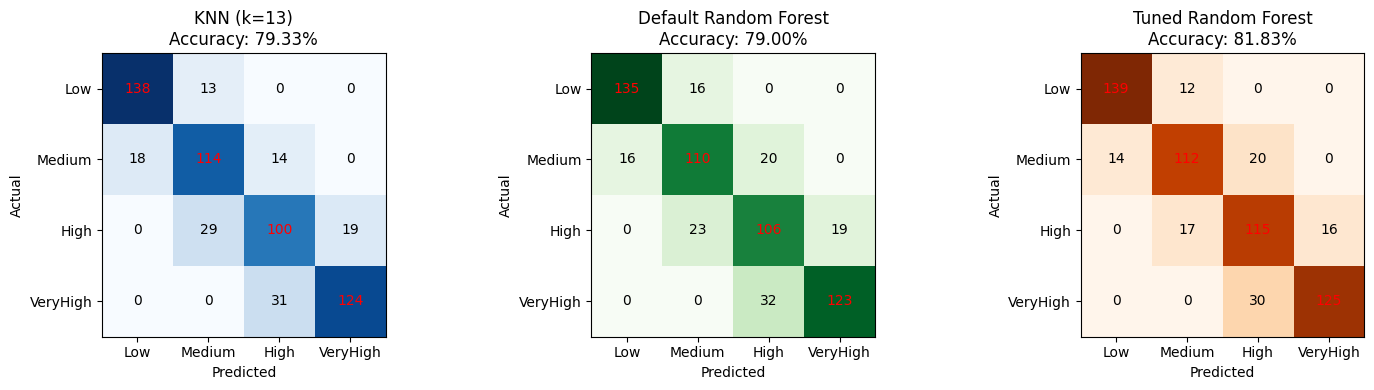


CONFUSION MATRIX RESULTS 

1. KNN (k=13) - Lazy Learner:
[[138  13   0   0]
 [ 18 114  14   0]
 [  0  29 100  19]
 [  0   0  31 124]]
   Correct predictions: 476/600

2. Default Random Forest - Eager Learner:
[[135  16   0   0]
 [ 16 110  20   0]
 [  0  23 106  19]
 [  0   0  32 123]]
   Correct predictions: 474/600

3. Tuned Random Forest - Eager Learner:
[[139  12   0   0]
 [ 14 112  20   0]
 [  0  17 115  16]
 [  0   0  30 125]]
   Correct predictions: 491/600

FINAL COMPARISON
Model                     Accuracy   Type      
--------------------------------------------------
KNN (k=13)                79.33%     Lazy      
Default Random Forest     79.00%     Eager     
Tuned Random Forest       81.83%     Eager     

 Tuned Random Forest with 81.83% accuracy


In [26]:
# STEP 6: Evaluate All Models with Confusion Matrices

print(" MODEL EVALUATION")

# Get confusion matrices
from sklearn.metrics import confusion_matrix

# KNN confusion matrix
cm_knn = confusion_matrix(y_test, knn_predictions, labels=['Low', 'Medium', 'High', 'VeryHigh'])

# Default RF confusion matrix
cm_randomforest_default = confusion_matrix(y_test, randomforest_predictions, labels=['Low', 'Medium', 'High', 'VeryHigh'])

# Tuned RF confusion matrix
cm_randomforest_tuned = confusion_matrix(y_test, randomforest_tuned_predictions, labels=['Low', 'Medium', 'High', 'VeryHigh'])

# Plot all confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_names = ['Low', 'Medium', 'High', 'VeryHigh']

# KNN
im1 = axes[0].imshow(cm_knn, cmap='Blues')
axes[0].set_title(f'KNN (k=13)\nAccuracy: {knn_accuracy:.2%}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(class_names)
axes[0].set_yticklabels(class_names)

# Add numbers
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, cm_knn[i, j], ha='center', va='center', color='red' if i == j else 'black')

# Default RF
im2 = axes[1].imshow(cm_randomforest_default, cmap='Greens')
axes[1].set_title(f'Default Random Forest\nAccuracy: {randomforest_accuracy:.2%}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(class_names)
axes[1].set_yticklabels(class_names)

for i in range(4):
    for j in range(4):
        axes[1].text(j, i, cm_randomforest_default[i, j], ha='center', va='center', color='red' if i == j else 'black')

# Tuned RF
im3 = axes[2].imshow(cm_randomforest_tuned, cmap='Oranges')
axes[2].set_title(f'Tuned Random Forest\nAccuracy: {best_randomforest_accuracy:.2%}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(class_names)
axes[2].set_yticklabels(class_names)

for i in range(4):
    for j in range(4):
        axes[2].text(j, i, cm_randomforest_tuned[i, j], ha='center', va='center', color='red' if i == j else 'black')

plt.tight_layout()
plt.show()

# Print detailed results
print("\nCONFUSION MATRIX RESULTS ")

print("\n1. KNN (k=13) - Lazy Learner:")
print(cm_knn)
print(f"   Correct predictions: {cm_knn.diagonal().sum()}/{len(y_test)}")

print("\n2. Default Random Forest - Eager Learner:")
print(cm_randomforest_default)
print(f"   Correct predictions: {cm_randomforest_default.diagonal().sum()}/{len(y_test)}")

print("\n3. Tuned Random Forest - Eager Learner:")
print(cm_randomforest_tuned)
print(f"   Correct predictions: {cm_randomforest_tuned.diagonal().sum()}/{len(y_test)}")

# Summary comparison
print("\n" + "=" * 50)
print("FINAL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':<10} {'Type':<10}")
print("-" * 50)
print(f"{'KNN (k=13)':<25} {knn_accuracy:.2%}     {'Lazy':<10}")
print(f"{'Default Random Forest':<25} {randomforest_accuracy:.2%}     {'Eager':<10}")
print(f"{'Tuned Random Forest':<25} {best_randomforest_accuracy:.2%}     {'Eager':<10}")
print("=" * 50)
print(f"\n Tuned Random Forest with {best_randomforest_accuracy:.2%} accuracy")